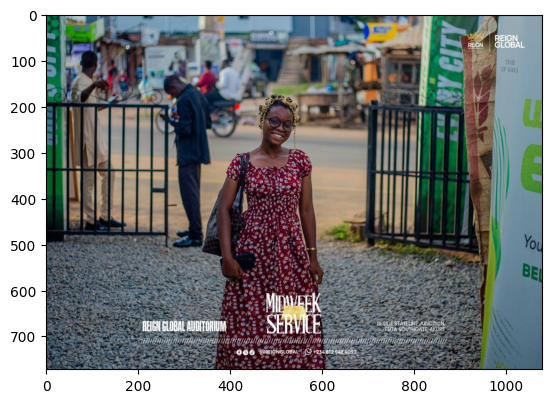

In [3]:
#Canny Edge Detection
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
import os, sys

image = cv.imread('../assets/favour.jpg')

image.size
img = cv.cvtColor(image, cv.COLOR_BGR2RGB)
plt.imshow(img)

(Text(0.5, 1.0, 'Canny'), ([], []), ([], []))

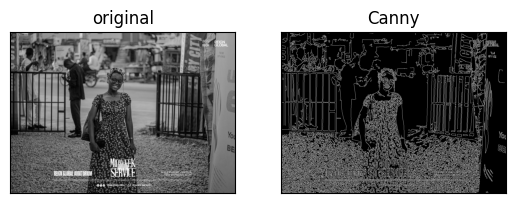

In [4]:
image = cv.imread('../assets/favour.jpg', cv.IMREAD_GRAYSCALE)
#plt.imshow(image, cmap= 'gray')
image.shape

edges = cv.Canny(image, 50, 200)
plt.subplot(121), plt.imshow(image, cmap= 'gray')
plt.title('original'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(edges, cmap= 'gray')
plt.title('Canny'), plt.xticks([]), plt.yticks([])


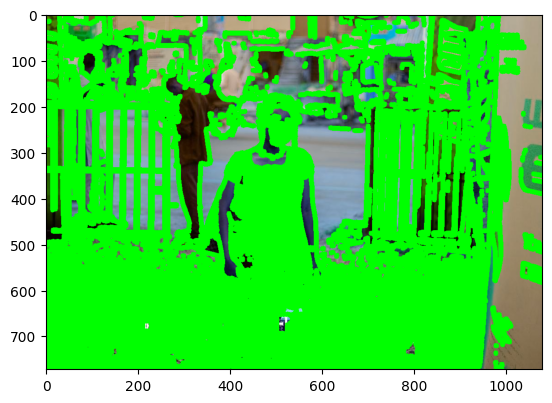

In [5]:
#Contour Processing
img = cv.imread('../assets/favour.jpg')
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
t_lower = 100 #lower Threshold
t_upper = 120 #upper Threshold
apperture_size = 3 #apperture_size(it could be either 3,5,7)
LGradient = True


edge = cv.Canny(gray, t_lower, t_upper, apertureSize=apperture_size, L2gradient=LGradient)
#find contour: its more like you are trying to find sharp edges, info on the lines
contours, hierarchy =cv.findContours(edge, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE) 
plt.imshow(edge)
cv.drawContours(img,contours,-1,(0,255,0) , 10)
plt.imshow(img)

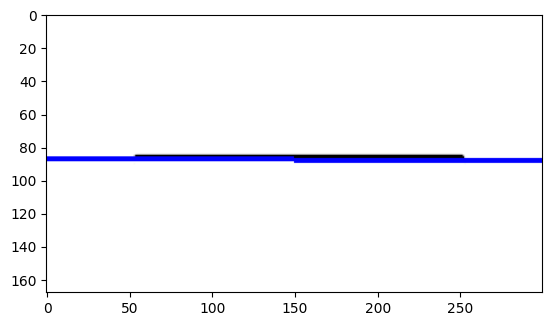

In [6]:
#Hough Transform(lines)
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt
image = cv.imread('../assets/sline.png')
rgb = cv.cvtColor(image, cv.COLOR_BGR2RGB)
gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

edge = cv.Canny(gray,100, 120, apertureSize=3)
lines = cv.HoughLines(edge, 1, np.pi/180, 196)

n_lines = len(lines)

for i in range(n_lines):
    for rho, theta in lines[i]:
        a = np.cos(theta)
        b = np.sin(theta)
        x0 =a*rho
        y0 = b*rho

        x1= int(x0 +1000*(-b))
        y1 = int (y0+ 1000*a)
        x2 = int(x0 - 1000*(-b))
        y2 = int(y0 - 1000*a)
        cv.line(image, (x1, y1), (x2, y2),(0,0, 255), 2)
plt.imshow(image)

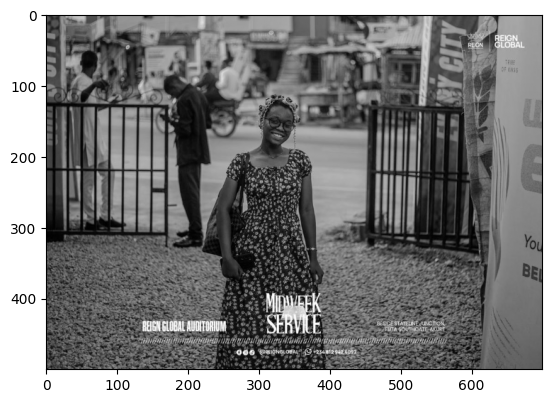

In [7]:
#Image Segmentation
image = cv.imread('../assets/favour.jpg')

image = cv.resize(image, (700,500))
#plt.imshow(image)

gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
plt.imshow(gray, cmap= 'gray')


(array([   5.,   89.,  248.,  421.,  611.,  856.,  924., 1105., 1179.,
        1166., 1291., 1414., 1475., 1610., 1637., 1749., 1803., 1815.,
        1945., 1932., 1995., 1960., 1924., 1887., 1905., 1863., 1754.,
        1688., 1610., 1606., 1513., 1494., 1429., 1405., 1448., 1452.,
        1370., 1387., 1402., 1442., 1401., 1457., 1382., 1412., 1501.,
        1431., 1415., 1502., 1464., 1404., 1458., 1529., 1411., 1549.,
        1506., 1559., 1628., 1542., 1610., 1768., 1852., 1864., 1793.,
        1830., 1913., 1881., 1890., 1968., 1891., 2002., 2047., 2007.,
        2130., 2134., 2209., 2077., 2171., 2110., 2109., 2108., 2176.,
        2082., 2103., 2210., 2161., 2213., 2214., 2239., 2190., 2274.,
        2246., 2396., 2313., 2311., 2422., 2581., 2607., 2653., 2770.,
        2696., 2736., 2822., 2780., 2701., 2763., 2753., 2692., 2707.,
        2758., 2670., 2648., 2724., 2933., 2936., 2946., 2772., 2815.,
        2654., 2614., 2635., 2518., 2425., 2407., 2308., 2360., 2447.,
      

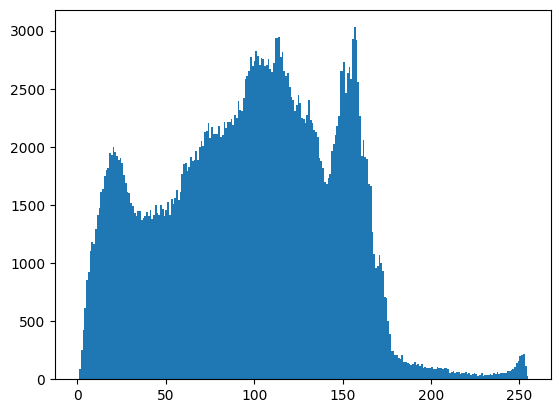

In [8]:
plt.hist(gray.ravel(), 256)

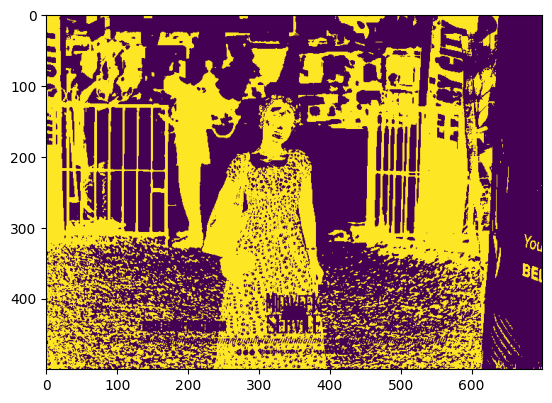

In [9]:
#otsu binarization

ret, binary_img = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
plt.imshow(binary_img)

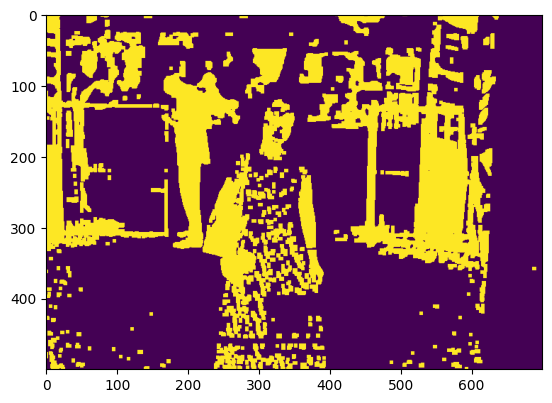

In [10]:
#Noise Removal: Denoising
kernel = cv.getStructuringElement(cv.MORPH_RECT, (3,3))
#filter = np.ones((3,3))
opening = cv.morphologyEx(binary_img,cv.MORPH_OPEN, kernel, iterations=2)
plt.imshow(opening)

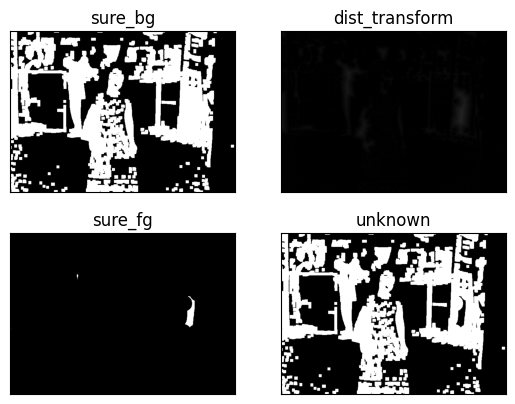

In [11]:
#fig, axes = plt.subplots(nrows= 2, ncols= 2, figsize=(8,8))


sure_bg = cv.dilate(opening, kernel, iterations=2) #background seperation
#axes[0,0].imshow(sure_bg)
#axes[0,0].set_title('sure_bg')
dist_transform = cv.distanceTransform(binary_img, cv.DIST_L2, 5)
#axes[1,1].imshow(dist_transform)
#axes[1,1].set_title('dist_transform')
ret, sure_fg =cv.threshold(dist_transform,0.7*dist_transform.max(), 255, 0)

sure_fg = np.uint8(sure_fg)
#axes[1,0].imshow(sure_fg)
#axes[1,0].set_title('sure_fg')
unknown = cv.subtract(sure_bg, sure_fg)
#axes[0,1].imshow(unknown)
#axes[0,1].set_title('unknown')

function_names= [sure_bg, dist_transform, sure_fg, unknown]
titles = ['sure_bg', 'dist_transform', 'sure_fg', 'unknown']

for i in range(4):
    plt.subplot(2,2,i+1), plt.imshow(function_names[i], 'gray', vmax= 255, vmin=0)
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])

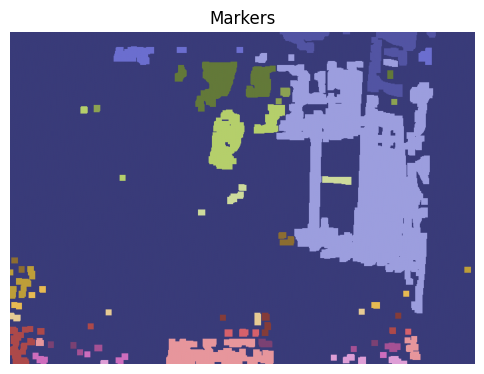

In [12]:
#marker labeling
ret, markers = cv.connectedComponents(sure_bg)
markers = markers + 1
markers[unknown == 225]= 0


fig, ax =plt.subplots(figsize=(6,6))
ax.imshow(markers, cmap='tab20b')
ax.set_title('Markers')
ax.axis('off')
plt.show()

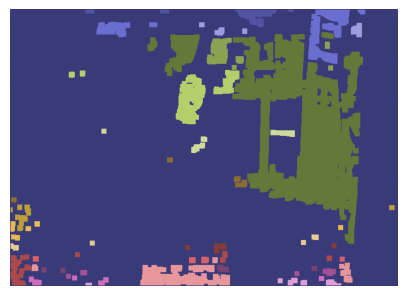

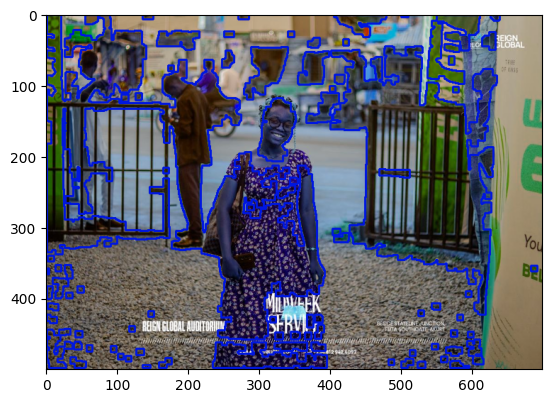

In [14]:
#watershed Algorithm
markers = cv.watershed(image, markers)
fig, ax = plt.subplots(figsize= (5,5))
ax.imshow(markers, cmap= 'tab20b')
ax.axis('off')
plt.show()


labels = np.unique(markers)
colns = []

for label in labels[2:]:
    target = np.where(markers== label, 255, 0).astype(np.uint8)
    
    contours, hierarchy =cv.findContours(target, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)
    colns.append(contours[0])

    img = cv.drawContours(image, colns, -1, color=(0, 23, 223), thickness=2)
    plt.imshow(img)
    

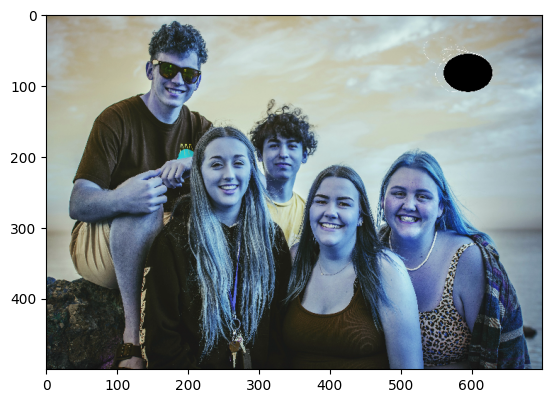

In [ ]:
#image restoration and image inpainting
img = cv.imread('../assets/pratice.jpg')
damaged_img = cv.resize(img, (700, 500))
plt.imshow(damaged_img)


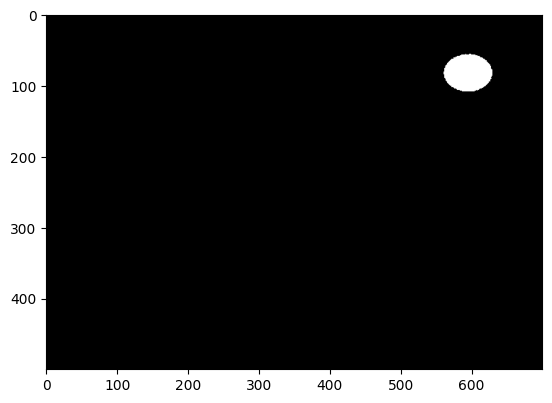

In [24]:

height, width = damaged_img.shape[0], damaged_img.shape[1]
for i in range (height):
    for j in range(width):
        if damaged_img[i,j].sum() > 0:
           damaged_img[i,j]=0
        else:
            damaged_img[i,j]= [255,255,255]
#save mask
mask = damaged_img
cv.imwrite('mask.jpg', mask)
plt.imshow(mask)




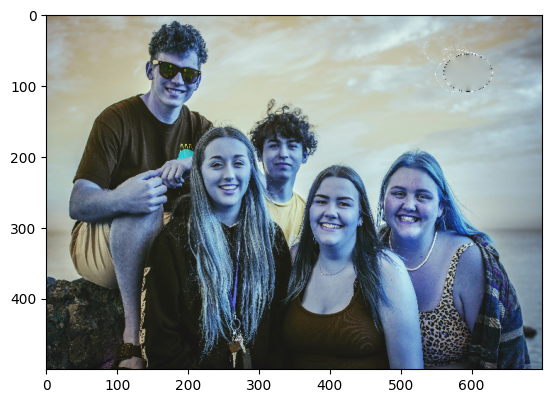

In [28]:
mask = cv.imread('../assets/mask.jpg',0)

#inpaint
dst = cv.inpaint(damaged_img, mask, 200, cv.INPAINT_TELEA)

plt.imshow(dst)